In [3]:
import sys
sys.path.append('../src')
from EEG_loader import load_eeg_dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df, raws = load_eeg_dataset(
    edf_dir='../Kural_Dataset/Recordings',
    demographics_csv='../Kural_Dataset/Demographics.csv'
)
#df

In [5]:
print(f"Files loaded: {len(raws)} out of {len(df)}")
print(df['load_error'].value_counts(dropna=False))

# check annotation status
df['annotation_status'].value_counts()

Files loaded: 100 out of 100
load_error
None    100
Name: count, dtype: int64


annotation_status
ok    100
Name: count, dtype: int64

In [6]:
# check frequency sampling rates
df['sfreq_hz'].value_counts()

# frequency sampling rate discrepancy with paper

sfreq_hz
500.0    100
Name: count, dtype: int64

In [7]:
# check number of EEG channels per participant

df['n_channels_total'].value_counts()
df['n_eeg_channels'].value_counts()

n_eeg_channels
25    97
19     3
Name: count, dtype: int64

In [8]:
# which files have 19 channels
odd_files = df[df['n_eeg_channels'] == 19]['file_id'].tolist()
print("Files with 19 EEG channels:", odd_files)
print(df[df['file_id'].isin(odd_files)][['file_id', 'label', 'age', 'gender']])

Files with 19 EEG channels: ['S33', 'S65', 'S96']
   file_id      label  age gender
33     S33  Epileptic    2      F
65     S65  Epileptic   41      F
96     S96  Epileptic   14      F


In [9]:
# compare channel names
normal_file = df[df['n_eeg_channels'] == 25]['file_id'].iloc[0]
odd_file = odd_files[0]

normal_chs = set(raws[normal_file].ch_names)
odd_chs = set(raws[odd_file].ch_names)

print("Channels in normal file but missing from odd file:")
print(normal_chs - odd_chs)

print("\nChannels in odd file but not in normal file:")
print(odd_chs - normal_chs)

Channels in normal file but missing from odd file:
{'E T10-Ref', 'E F10-Ref', 'E P10-Ref', 'E F9-Ref', 'E P9-Ref', 'E T9-Ref'}

Channels in odd file but not in normal file:
set()


In [10]:
# add reduced channel column to df
df['reduced_channels'] = df['n_eeg_channels'] == 19
#df

## Transient Properties

In [11]:
# summary stats per group
cols = ['duration_s', 'transient_onset_s', 'pre_transient_s', 'post_transient_s', 'frac_position']

summary = df.groupby('label')[cols].describe().T
summary

label                    Epileptic  Non_Epileptic
duration_s        count  54.000000      46.000000
                  mean   12.794296      12.432783
                  std     0.490653       0.860289
                  min    11.998000      10.998000
                  25%    12.998000      11.998000
                  50%    12.998000      12.998000
                  75%    12.998000      12.998000
                  max    13.998000      12.998000
transient_onset_s count  54.000000      46.000000
                  mean    6.318476       6.144613
                  std     0.632843       0.511044
                  min     2.330100       5.076900
                  25%     6.147025       5.905850
                  50%     6.432750       6.222100
                  75%     6.617100       6.527800
                  max     7.004300       6.875000
pre_transient_s   count  54.000000      46.000000
                  mean    6.318476       6.144613
                  std     0.632843       0.511044
                  min     2.330100       5.076900
                  25%     6.147025       5.905850
                  50%     6.432750       6.222100
                  75%     6.617100       6.527800
                  max     7.004300       6.875000
post_transient_s  count  54.000000      46.000000
                  mean    6.475820       6.288167
                  std     0.681682       0.495546
                  min     5.587700       5.083000
                  25%     6.166000       5.950750
                  50%     6.385400       6.434100
                  75%     6.641025       6.689400
                  max    10.667900       6.893800
frac_position     count  54.000000      46.000000
                  mean    0.494031       0.494143
                  std     0.047023       0.021483
                  min     0.179300       0.438200
                  25%     0.487075       0.477150
                  50%     0.502750       0.496250
                  75%     0.512875       0.508550
                  max     0.538900       0.537800

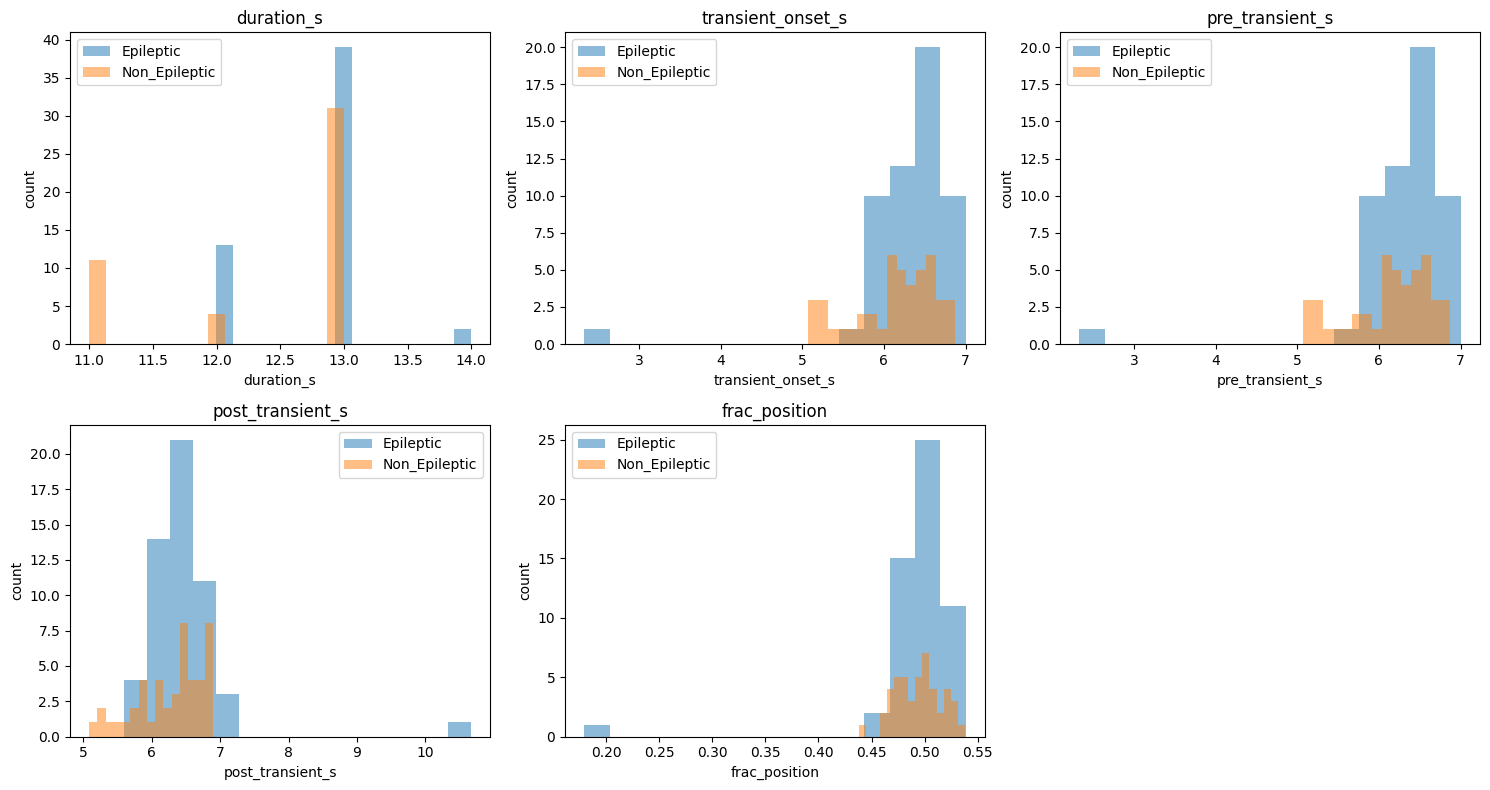

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    for label, group in df.groupby('label'):
        axes[i].hist(group[col], bins=15, alpha=0.5, label=label)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('count')
    axes[i].legend()

axes[-1].axis('off')  # unused subplot
plt.tight_layout()
plt.show()

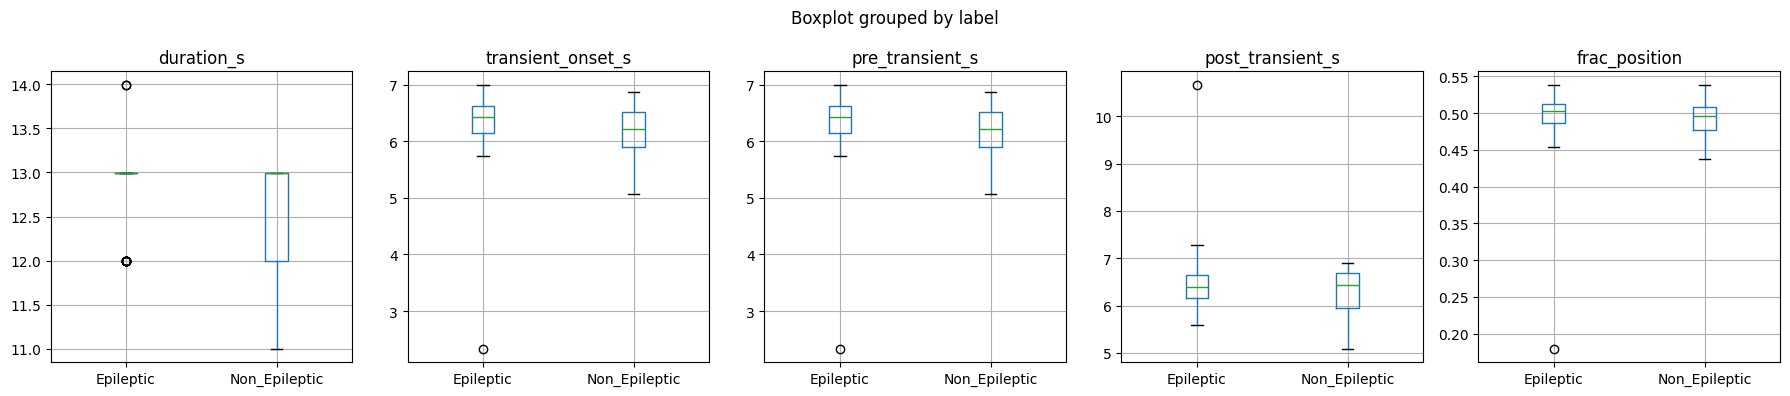

In [13]:
fig, axes = plt.subplots(1, len(cols), figsize=(18, 4))

for i, col in enumerate(cols):
    df.boxplot(column=col, by='label', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

In [14]:
# epochs where the transient is very close to the start or end
edge_cases = df[(df['frac_position'] < 0.2) | (df['frac_position'] > 0.8)]
print("Transients near epoch edges:")
print(edge_cases[['file_id', 'label', 'pre_transient_s', 'post_transient_s', 'duration_s', 'frac_position']])

Transients near epoch edges:
   file_id      label  pre_transient_s  post_transient_s  duration_s  \
82     S82  Epileptic           2.3301           10.6679      12.998   

    frac_position  
82         0.1793  


In [15]:
raw = raws['S82']
print(raw.annotations.onset)
print(raw.annotations.description)
print(raw.times[-1])

[0.       2.330101]
['Marker: Review Progress' 'Marker: Annotation']
12.998


In [16]:
# extra annotataions in the EDF files
hawk = df[df['all_annotation_labels'].str.contains('Hawk_Cmd_Log')]
print(f"Files with Hawk_Cmd_Log: {len(hawk)}")
print(hawk[['file_id', 'label']])

Files with Hawk_Cmd_Log: 11
   file_id          label
19     S19      Epileptic
20     S20  Non_Epileptic
42     S42      Epileptic
44     S44      Epileptic
45     S45      Epileptic
48     S48  Non_Epileptic
61     S61  Non_Epileptic
66     S66  Non_Epileptic
73     S73  Non_Epileptic
89     S89  Non_Epileptic
94     S94      Epileptic


In [17]:
df['has_hawk_log'] = df['all_annotation_labels'].str.contains('Hawk_Cmd_Log')

## Metadata EDA

In [18]:
print(df['label'].value_counts())

label
Epileptic        54
Non_Epileptic    46
Name: count, dtype: int64


In [19]:
print(df['gender'].value_counts())
print()
print(df.groupby('label')['gender'].value_counts())

gender
F    60
M    40
Name: count, dtype: int64

label          gender
Epileptic      M         29
               F         25
Non_Epileptic  F         35
               M         11
Name: count, dtype: int64


In [20]:
# age properties
df.groupby('label')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
Epileptic,54.0,32.481481,18.886694,2.0,19.50,29.0,43.25,77.0
Non_Epileptic,46.0,37.608696,19.671161,11.0,20.25,34.5,52.75,89.0


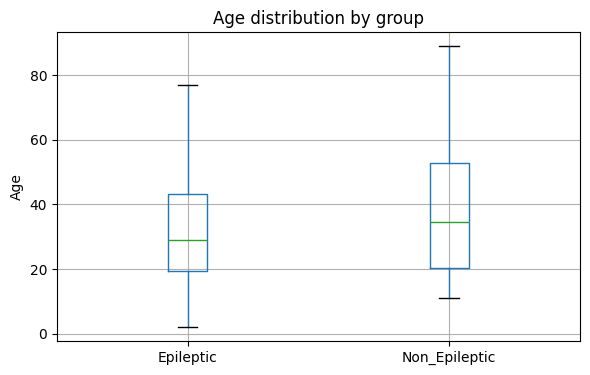

In [21]:
fig, ax = plt.subplots(figsize=(6, 4))

df.boxplot(column='age', by='label', ax=ax)
ax.set_title('Age distribution by group')
ax.set_xlabel('')
ax.set_ylabel('Age')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [22]:
# missing values
df.isnull().sum()

file_id                    0
sample_id                  0
label                      0
label_binary               0
gender                     0
age                        0
sfreq_hz                   0
duration_s                 0
n_channels_total           0
n_eeg_channels             0
n_annotations_total        0
n_transient_markers        0
annotation_status          0
transient_onset_s          0
pre_transient_s            0
post_transient_s           0
frac_position              0
all_annotation_labels      0
load_error               100
reduced_channels           0
has_hawk_log               0
dtype: int64

# signal level EDA

## Transient amplitude

In [23]:
# define peri-transient window in seconds
pre_ms = 0.1   # 100ms before marker
post_ms = 0.1  # 100ms after marker

# get the channel names from any full file (excluding EKG)
reference_file = 'S01'
eeg_ch_names = [ch for ch in raws[reference_file].ch_names if 'EKG' not in ch]

# store results
peak_amp_records = []

for file_id, raw in raws.items():
    sfreq = raw.info['sfreq']
    
    # get transient onset time
    transient_anns = [a for a in raw.annotations if 'Annotation' in a['description']]
    if len(transient_anns) != 1:
        continue
    t_onset = transient_anns[0]['onset']
    
    # define window sample indices
    samp_start = int((t_onset - pre_ms) * sfreq)
    samp_end   = int((t_onset + post_ms) * sfreq)
    
    # get EEG channels only
    eeg_chs = [ch for ch in raw.ch_names if 'EKG' not in ch]
    eeg_idx  = [raw.ch_names.index(ch) for ch in eeg_chs]
    
    # extract window
    data, _ = raw[eeg_idx, samp_start:samp_end]  # shape: (n_channels, n_samples)
    data_uv  = data * 1e6  # convert to microvolts
    
    # peak absolute amplitude per channel
    peak_per_channel = np.abs(data_uv).max(axis=1)  # shape: (n_channels,)
    
    record = {'file_id': file_id}
    for ch_name, peak in zip(eeg_chs, peak_per_channel):
        record[ch_name] = round(peak, 4)
    
    peak_amp_records.append(record)

# build dataframe: rows = files, columns = channels
peak_amp_df = pd.DataFrame(peak_amp_records).set_index('file_id')
peak_amp_df = peak_amp_df.sort_index()

print(f"Shape: {peak_amp_df.shape}")
print(peak_amp_df.head())

Shape: (100, 25)
         E FP1-Ref  E FP2-Ref  E F3-Ref  E F4-Ref  E C3-Ref  E C4-Ref  \
file_id                                                                 
S01        16.9953    25.0049   17.0011   40.9995   18.9998   80.0006   
S02        35.6518    43.8993   21.6684   19.3254   11.3501   11.2218   
S03        64.9930    76.9883   76.9883  120.9815   37.9966   39.0044   
S04        45.9979    34.9934   34.9937   27.0034   43.9939   13.9998   
S05        82.9906    86.9793   60.9907   50.9938   28.0015   40.9953   

         E P3-Ref  E P4-Ref  E O1-Ref  E O2-Ref  ...  E P8-Ref  E P9-Ref  \
file_id                                          ...                       
S01       20.0001   18.0009   18.0006   26.9997  ...   13.9927   26.0016   
S02       11.5414   19.5887   29.4629   41.8983  ...   58.5778   43.2774   
S03       35.0002   16.9971   62.9981   54.0049  ...   43.9987   70.9892   
S04       29.9927   13.9986   39.0036   32.0009  ...   37.0034   45.0028   
S05       31.00

In [24]:
# merge with labels
peak_amp_df['label'] = peak_amp_df.index.map(df.set_index('file_id')['label'])

# global peak: single highest amplitude across all channels
peak_amp_df['global_peak_uv'] = peak_amp_df[eeg_ch_names].max(axis=1)

# mean peak: average peak amplitude across all channels
peak_amp_df['mean_peak_uv'] = peak_amp_df[eeg_ch_names].mean(axis=1)

# dominant channel: which channel had the highest peak
peak_amp_df['dominant_channel'] = peak_amp_df[eeg_ch_names].idxmax(axis=1)

# focality ratio: global peak / mean peak
# high value = transient is focal (one channel much larger than others)
# low value  = transient is spatially widespread
peak_amp_df['focality_ratio'] = peak_amp_df['global_peak_uv'] / peak_amp_df['mean_peak_uv']

print(peak_amp_df[['label', 'global_peak_uv', 'mean_peak_uv', 'dominant_channel', 'focality_ratio']].head(10))

                 label  global_peak_uv  mean_peak_uv dominant_channel  \
file_id                                                                 
S01      Non_Epileptic         80.0006     26.679520         E C4-Ref   
S02          Epileptic         74.6211     34.754084        E T10-Ref   
S03          Epileptic        120.9815     56.275544         E F4-Ref   
S04      Non_Epileptic         54.9922     34.278572         E F9-Ref   
S05          Epileptic        100.9846     54.235556         E F7-Ref   
S06      Non_Epileptic        280.9580     55.919144         E P8-Ref   
S07          Epileptic        106.9837     38.596616        E F10-Ref   
S08          Epileptic         83.9974     29.477904        E T10-Ref   
S09          Epileptic         96.9852     32.235500        E F10-Ref   
S10      Non_Epileptic         82.9873     40.238768         E T7-Ref   

         focality_ratio  
file_id                  
S01            2.998577  
S02            2.147117  
S03            2.14

In [25]:
# summary statistics by group
summary_cols = ['global_peak_uv', 'mean_peak_uv', 'focality_ratio']
print(peak_amp_df.groupby('label')[summary_cols].describe().T)

label                  Epileptic  Non_Epileptic
global_peak_uv count   54.000000      46.000000
               mean   130.391750      93.624089
               std     79.214717      69.765986
               min     34.003100      35.001300
               25%     80.247550      55.743700
               50%    113.480150      71.493500
               75%    139.992525      96.994050
               max    465.985800     407.998500
mean_peak_uv   count   54.000000      46.000000
               mean    56.526894      38.418617
               std     47.343356      24.558456
               min     16.878352      13.960376
               25%     34.272806      26.006483
               50%     46.578194      31.218156
               75%     57.509651      43.158511
               max    324.529244     161.762732
focality_ratio count   54.000000      46.000000
               mean     2.477286       2.561686
               std      0.604574       1.339750
               min      1.422156       1

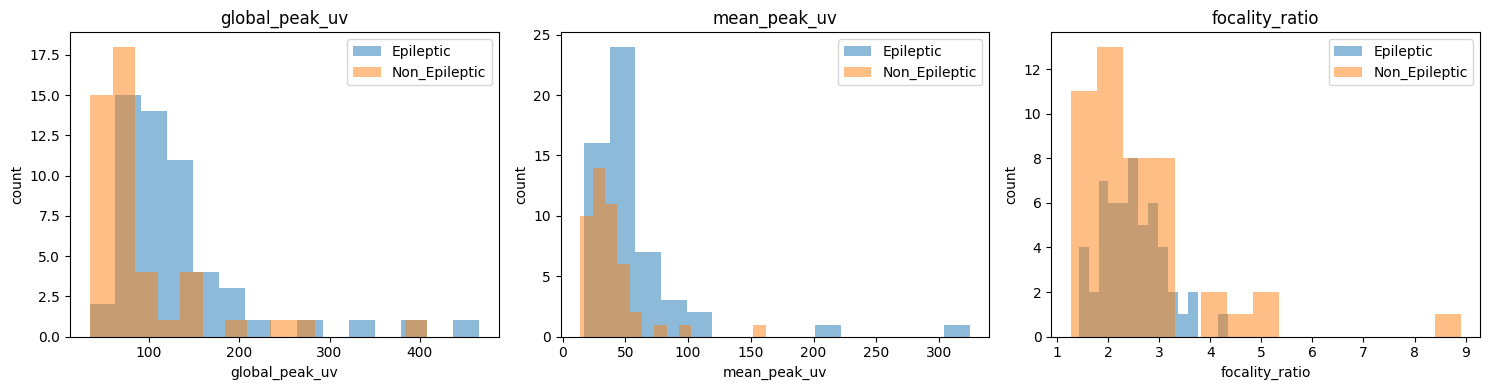

In [26]:
# visualise distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, summary_cols):
    for label, group in peak_amp_df.groupby('label'):
        ax.hist(group[col], bins=15, alpha=0.5, label=label)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('count')
    ax.legend()

plt.tight_layout()
plt.show()

In [27]:
# flag any files with unusually high global peak (potential artefact)
threshold = 200  # microvolts, well above typical EEG
outliers = peak_amp_df[peak_amp_df['global_peak_uv'] > threshold]
print(f"Files with global peak above {threshold} uV:")
print(outliers[['label', 'global_peak_uv', 'dominant_channel', 'focality_ratio']])

Files with global peak above 200 uV:
                 label  global_peak_uv dominant_channel  focality_ratio
file_id                                                                
S06      Non_Epileptic        280.9580         E P8-Ref        5.024362
S39          Epileptic        382.0350        E FP1-Ref        1.890082
S44          Epileptic        465.9858        E FP2-Ref        1.435882
S49      Non_Epileptic        407.9985         E Pz-Ref        8.901221
S55          Epileptic        213.0195        E FP1-Ref        3.677758
S74      Non_Epileptic        239.9927        E FP2-Ref        2.386752
S84      Non_Epileptic        205.0188        E F10-Ref        1.267404
S93          Epileptic        280.0256         E F3-Ref        2.435055
S97          Epileptic        336.9486         E T8-Ref        3.023760


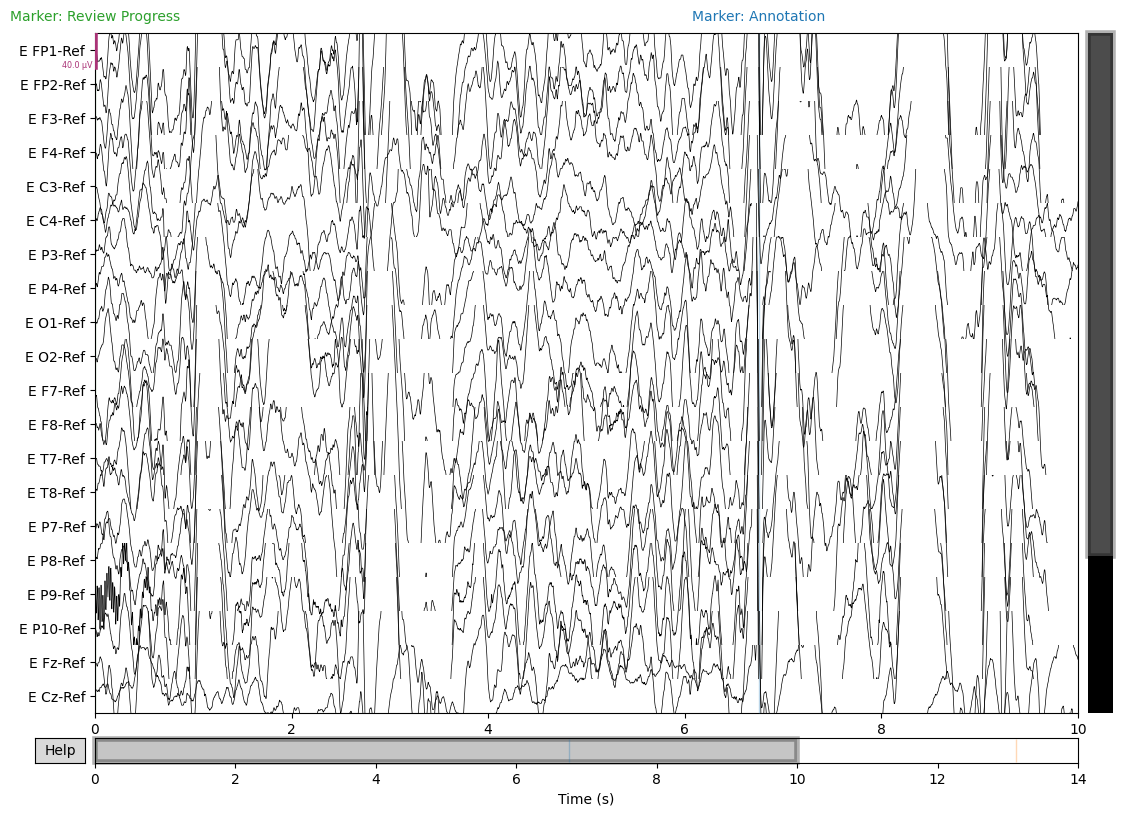

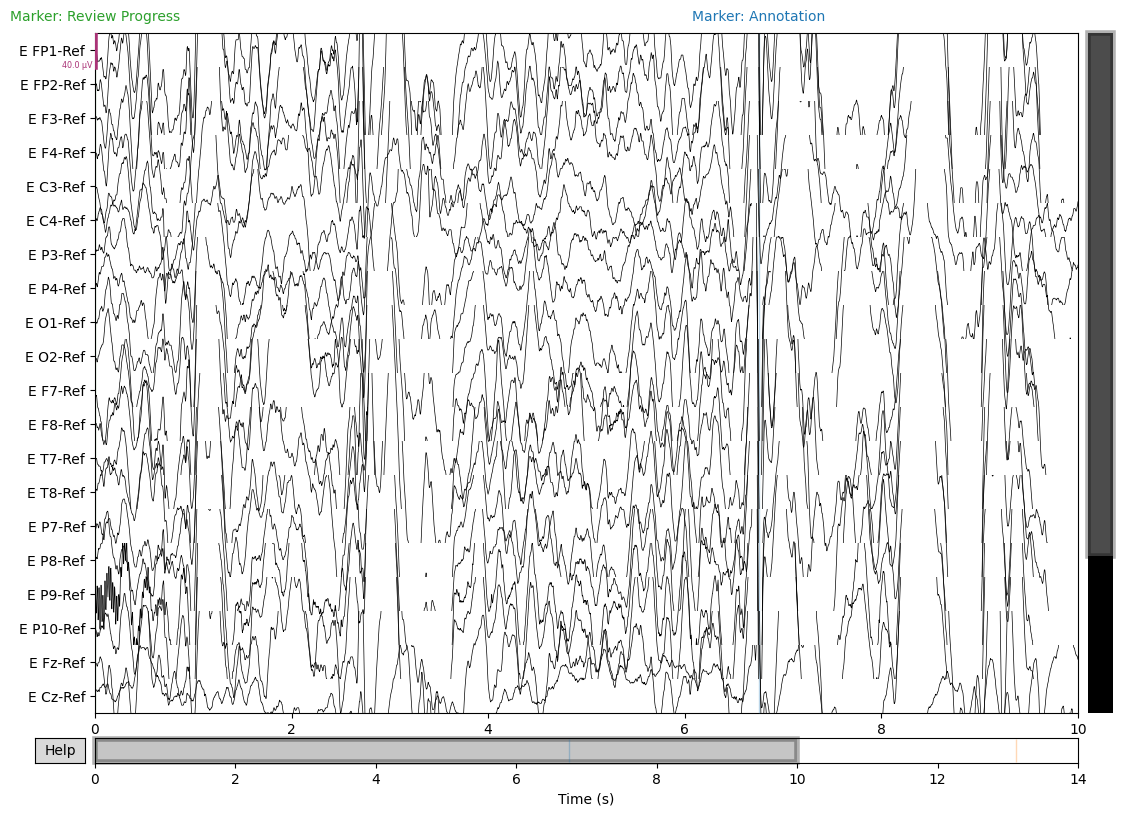

In [28]:
raws['S44'].plot(block=True) # epileptic

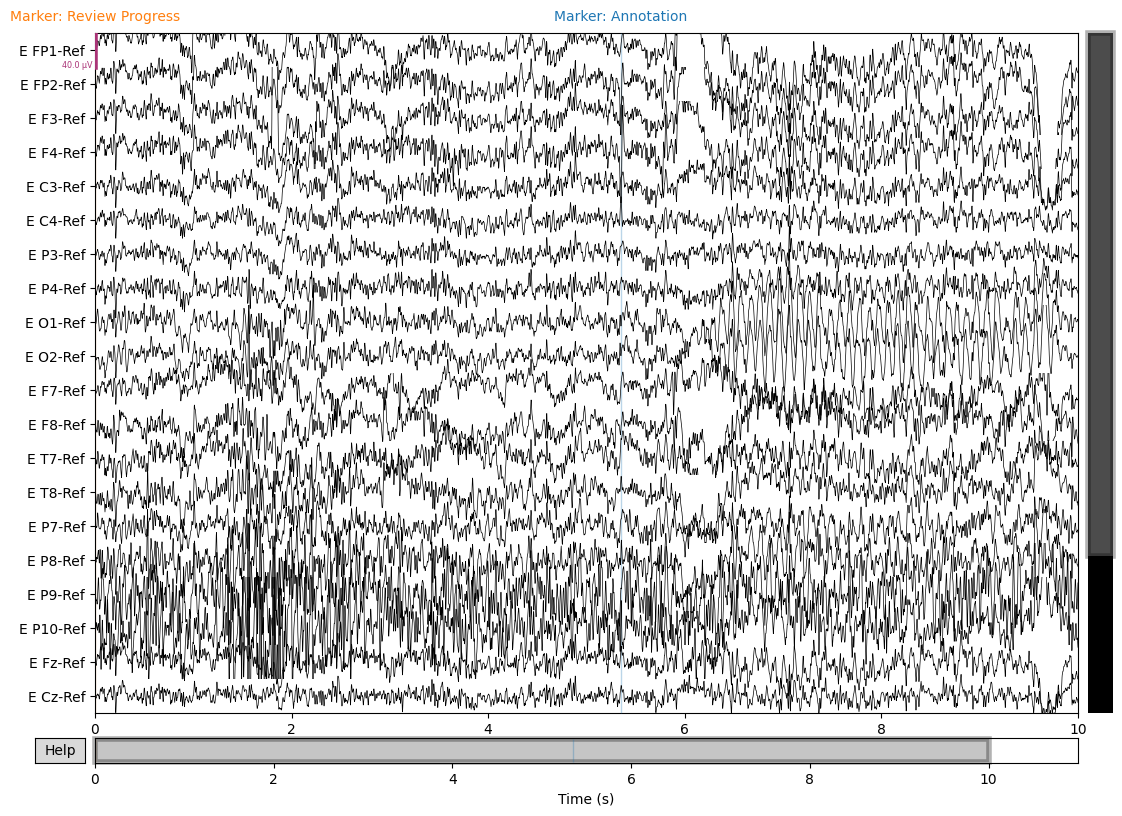

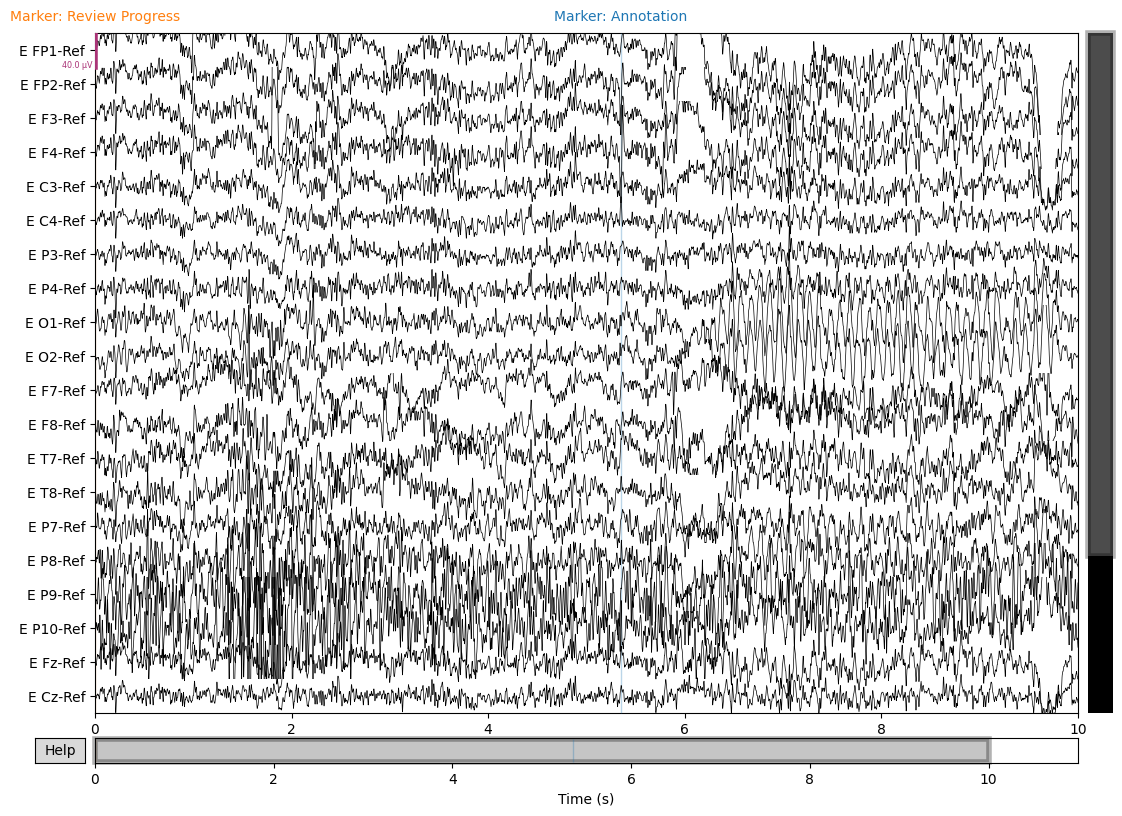

In [29]:
raws['S49'].plot(block=True) # non epileptic

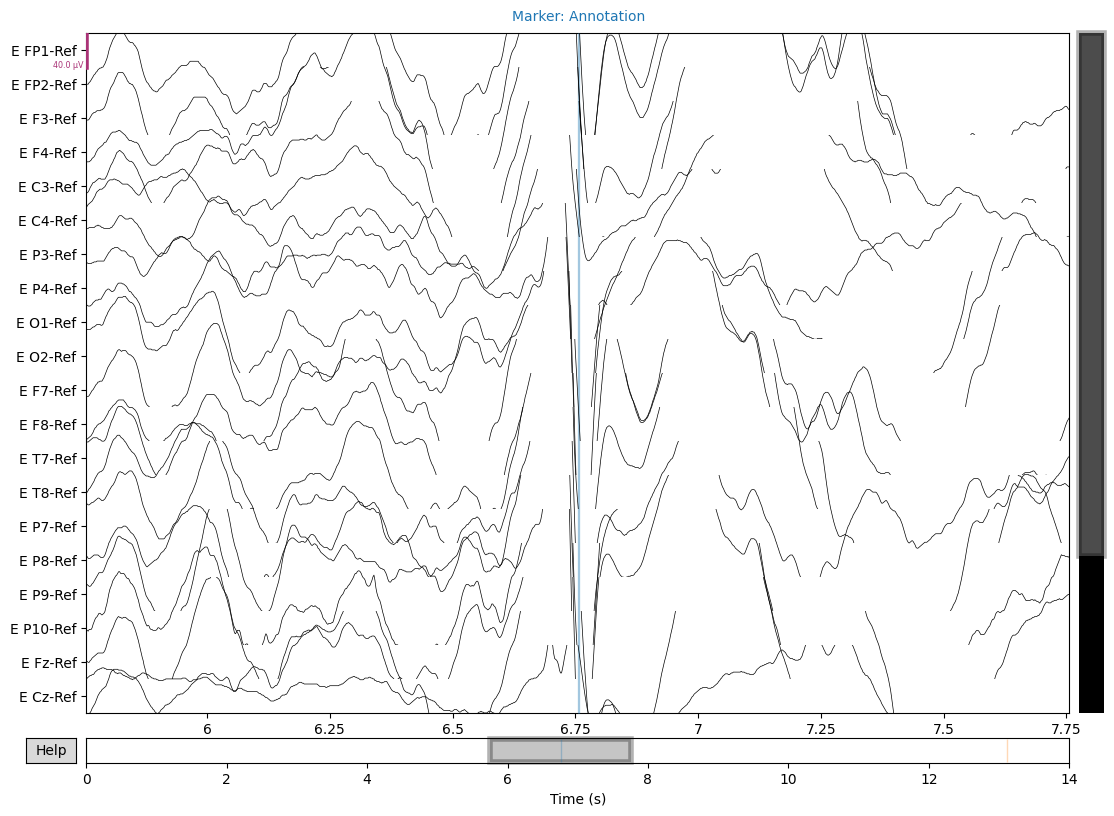

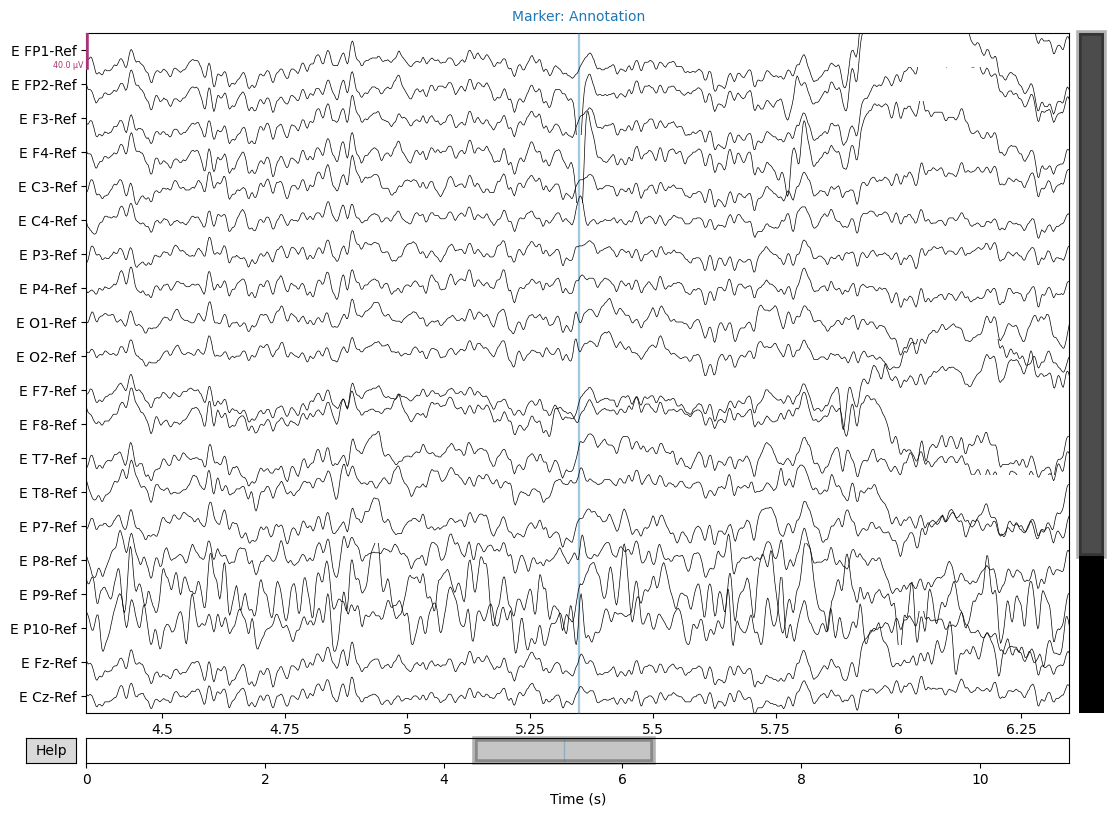

In [30]:
# zoom in: show only 1 second either side of the transient
for fid in ['S44', 'S49']:
    raw = raws[fid]
    t_onset = [a['onset'] for a in raw.annotations if 'Annotation' in a['description']][0]
    raw.plot(start=t_onset - 1, duration=2, block=True, title=fid)

In [31]:
peak_amp_df['high_amplitude_flag'] = peak_amp_df['global_peak_uv'] > 200
df['high_amplitude_flag'] = df['file_id'].map(peak_amp_df['high_amplitude_flag'])
df

,file_id,sample_id,label,label_binary,gender,age,sfreq_hz,duration_s,n_channels_total,n_eeg_channels,...,annotation_status,transient_onset_s,pre_transient_s,post_transient_s,frac_position,all_annotation_labels,load_error,reduced_channels,has_hawk_log,high_amplitude_flag
0,S01,S1,Non_Epileptic,0,F,34,500.0,12.998,26,25,...,ok,6.6081,6.6081,6.3899,0.5084,Marker: | Marker: Annotation,None,False,False,False
1,S02,S2,Epileptic,1,M,77,500.0,11.998,26,25,...,ok,5.8761,5.8761,6.1219,0.4898,Marker: Review Progress | Marker: Annotation,None,False,False,False
2,S03,S3,Epileptic,1,M,14,500.0,12.998,26,25,...,ok,6.0685,6.0685,6.9295,0.4669,Marker: Review Progress | Marker: Annotation,None,False,False,False
3,S04,S4,Non_Epileptic,0,M,12,500.0,11.998,26,25,...,ok,5.2574,5.2574,6.7406,0.4382,Marker: | Marker: Annotation,None,False,False,False
4,S05,S5,Epileptic,1,M,46,500.0,12.998,26,25,...,ok,6.3482,6.3482,6.6498,0.4884,Marker: Review Progress | Marker: Annotation,None,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,S95,S95,Non_Epileptic,0,F,25,500.0,12.998,26,25,...,ok,6.1042,6.1042,6.8938,0.4696,Marker: Review Progress | Marker: Annotation,None,False,False,False
96,S96,S96,Epileptic,1,F,14,500.0,12.998,20,19,...,ok,6.6711,6.6711,6.3269,0.5132,Marker: Review Progress | Marker: Annotation,None,True,False,False
97,S97,S97,Epileptic,1,F,30,500.0,13.998,26,25,...,ok,6.7173,6.7173,7.2807,0.4799,Marker: Review Progress | Marker: Annotation,None,False,False,True
98,S98,S98,Non_Epileptic,0,F,38,500.0,12.998,26,25,...,ok,6.4722,6.4722,6.5258,0.4979,Marker: Review Progress | Marker: Annotation,None,False,False,False


## Clear and unclear positives

In [32]:
CLEAR_POSITIVES = [1, 4, 6, 7, 8, 12, 17, 18, 22, 25, 28, 30, 43, 44, 45, 49,
                   52, 64, 66, 86, 96, 99]

UNCLEAR_POSITIVES = [2, 10, 13, 15, 20, 26, 29, 32, 35, 36, 38, 40, 41, 46, 51,
                     54, 55, 57, 59, 61, 68, 69, 71, 74, 75, 78, 81, 85, 89,
                     92, 93, 95]

NEGATIVES = [0, 3, 5, 9, 11, 14, 16, 19, 21, 23, 24, 27, 31, 33, 34, 37, 39,
             42, 47, 48, 50, 53, 56, 58, 60, 62, 63, 65, 67, 70, 72, 73, 76,
             77, 79, 80, 82, 83, 84, 87, 88, 90, 91, 94, 97, 98]

def index_to_file_id(idx):
    return 'S' + str(idx + 1).zfill(2)

df['certainty'] = 'unknown'
df.loc[df['file_id'].isin([index_to_file_id(i) for i in CLEAR_POSITIVES]), 'certainty'] = 'clear_positive'
df.loc[df['file_id'].isin([index_to_file_id(i) for i in UNCLEAR_POSITIVES]), 'certainty'] = 'unclear_positive'
df.loc[df['file_id'].isin([index_to_file_id(i) for i in NEGATIVES]), 'certainty'] = 'negative'

print(df['certainty'].value_counts())
print(df[df['certainty'] == 'unknown'])

certainty
negative            46
unclear_positive    32
clear_positive      22
Name: count, dtype: int64
Empty DataFrame
Columns: [file_id, sample_id, label, label_binary, gender, age, sfreq_hz, duration_s, n_channels_total, n_eeg_channels, n_annotations_total, n_transient_markers, annotation_status, transient_onset_s, pre_transient_s, post_transient_s, frac_position, all_annotation_labels, load_error, reduced_channels, has_hawk_log, high_amplitude_flag, certainty]
Index: []

[0 rows x 23 columns]


In [33]:
df[['file_id', 'certainty']]

,file_id,certainty
0,S01,negative
1,S02,clear_positive
2,S03,unclear_positive
3,S04,negative
4,S05,clear_positive
...,...,...
95,S95,negative
96,S96,unclear_positive
97,S97,clear_positive
98,S98,negative


In [35]:
print(df.columns.tolist())

['file_id', 'sample_id', 'label', 'label_binary', 'gender', 'age', 'sfreq_hz', 'duration_s', 'n_channels_total', 'n_eeg_channels', 'n_annotations_total', 'n_transient_markers', 'annotation_status', 'transient_onset_s', 'pre_transient_s', 'post_transient_s', 'frac_position', 'all_annotation_labels', 'load_error', 'reduced_channels', 'has_hawk_log', 'high_amplitude_flag', 'certainty']


In [37]:
df.to_csv('../Kural_Dataset/eeg_summary.csv', index=False)

In [36]:
df

,file_id,sample_id,label,label_binary,gender,age,sfreq_hz,duration_s,n_channels_total,n_eeg_channels,...,transient_onset_s,pre_transient_s,post_transient_s,frac_position,all_annotation_labels,load_error,reduced_channels,has_hawk_log,high_amplitude_flag,certainty
0,S01,S1,Non_Epileptic,0,F,34,500.0,12.998,26,25,...,6.6081,6.6081,6.3899,0.5084,Marker: | Marker: Annotation,None,False,False,False,negative
1,S02,S2,Epileptic,1,M,77,500.0,11.998,26,25,...,5.8761,5.8761,6.1219,0.4898,Marker: Review Progress | Marker: Annotation,None,False,False,False,clear_positive
2,S03,S3,Epileptic,1,M,14,500.0,12.998,26,25,...,6.0685,6.0685,6.9295,0.4669,Marker: Review Progress | Marker: Annotation,None,False,False,False,unclear_positive
3,S04,S4,Non_Epileptic,0,M,12,500.0,11.998,26,25,...,5.2574,5.2574,6.7406,0.4382,Marker: | Marker: Annotation,None,False,False,False,negative
4,S05,S5,Epileptic,1,M,46,500.0,12.998,26,25,...,6.3482,6.3482,6.6498,0.4884,Marker: Review Progress | Marker: Annotation,None,False,False,False,clear_positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,S95,S95,Non_Epileptic,0,F,25,500.0,12.998,26,25,...,6.1042,6.1042,6.8938,0.4696,Marker: Review Progress | Marker: Annotation,None,False,False,False,negative
96,S96,S96,Epileptic,1,F,14,500.0,12.998,20,19,...,6.6711,6.6711,6.3269,0.5132,Marker: Review Progress | Marker: Annotation,None,True,False,False,unclear_positive
97,S97,S97,Epileptic,1,F,30,500.0,13.998,26,25,...,6.7173,6.7173,7.2807,0.4799,Marker: Review Progress | Marker: Annotation,None,False,False,True,clear_positive
98,S98,S98,Non_Epileptic,0,F,38,500.0,12.998,26,25,...,6.4722,6.4722,6.5258,0.4979,Marker: Review Progress | Marker: Annotation,None,False,False,False,negative
